# Predicting Airbnb Listing Prices with MLflow and AWS S3

**StayWise Data Science Team**

This notebook implements an end-to-end machine learning pipeline to predict nightly Airbnb listing prices in New York City. The workflow covers:

1. **Data Retrieval** — Loading the raw dataset from AWS S3
2. **Data Cleaning & Preprocessing** — Handling missing values, outliers, feature engineering
3. **Model Development** — Training and comparing Linear Regression, Random Forest, and XGBoost
4. **Experiment Tracking** — Logging all runs with MLflow and registering the best model


## Setup and Imports


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import boto3
import mlflow

import os

## 1. Dataset Retrieval from AWS S3

The raw Airbnb listings dataset is stored in an S3 bucket. We use `boto3` to retrieve it.

**Prerequisites:**

- AWS credentials configured via `aws configure`, environment variables (`AWS_ACCESS_KEY_ID`, `AWS_SECRET_ACCESS_KEY`), or IAM role.
- The CSV file uploaded to your S3 bucket.


### Create Bucket


In [2]:
S3_BUCKET = "aml-3303-airbnb-nyc-2019-listing"
AWS_REGION = "us-east-2"


s3 = boto3.client("s3")

try:
    s3.create_bucket(Bucket=S3_BUCKET, CreateBucketConfiguration={
                     "LocationConstraint": AWS_REGION})
    print(
        f"Bucket '{S3_BUCKET}' created successfully in region '{AWS_REGION}'.")

except Exception as e:
    print(f"Error creating bucket: {e}")

j:\MLflow\.mlflow\lib\site-packages\boto3\compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)


Bucket 'aml-3303-airbnb-nyc-2019-listing' created successfully in region 'us-east-2'.


### Upload dataset to the Bucket


In [3]:
files = ['./data/AB_NYC_2019.csv', './data/Ab Nyc2019 Data Dictionary.docx']
try:
    for file_path in files:
        s3.upload_file(file_path, S3_BUCKET, file_path.split('/')[-1])
        print(f"Uploaded file {file_path.split('/')[-1]} to s3://{S3_BUCKET}/")
except Exception as e:
    print(f"Error uploading file: {e}")

Uploaded file AB_NYC_2019.csv to s3://aml-3303-airbnb-nyc-2019-listing/
Uploaded file Ab Nyc2019 Data Dictionary.docx to s3://aml-3303-airbnb-nyc-2019-listing/


### Download the dataset


In [ ]:
os.makedirs("./downloaded", exist_ok=True)
file_location = "./downloaded/AB_NYC_2019.csv'"
try:
    response = s3.download_file(
        S3_BUCKET, 'AB_NYC_2019.csv', file_location)
    print("file downloaded successfully")

except Exception as e:
    print(f"Error downloading file: {e}")

file downloaded successfully


## 2. Data Overview

In [ ]:
df = pd.read_csv(file_location)

In [6]:
print("Dataset shape:", df.shape)
print("\nData types:\n")
print(df.dtypes)

Dataset shape: (48895, 16)

Data types:

id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object


In [7]:
print("Basic statistics:")
df.describe()

Basic statistics:


,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Missing values summary


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame(
    {"Missing Count": missing, "Percentage": missing_pct})
print("Missing Values:")
print(missing_df[missing_df["Missing Count"] > 0])

Missing Values:
                   Missing Count  Percentage
name                          16        0.03
host_name                     21        0.04
last_review                10052       20.56
reviews_per_month          10052       20.56


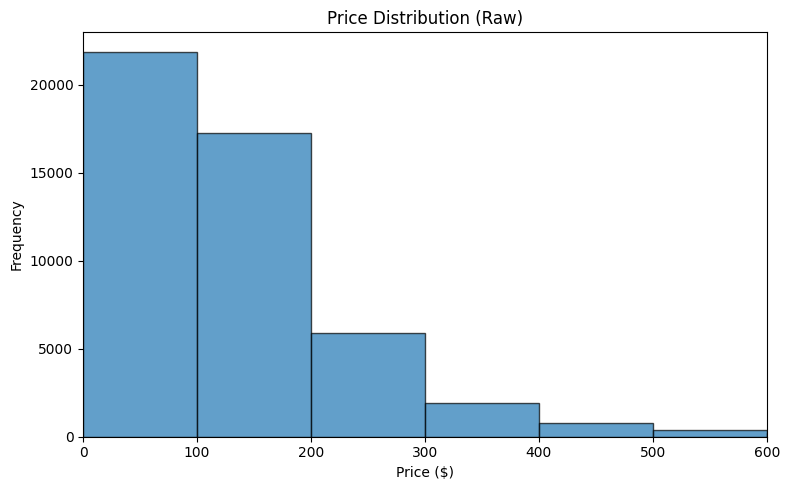

In [9]:
# Raw price distribution
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=100, edgecolor="black", alpha=0.7)
plt.xlim(0, 600)
plt.title("Price Distribution (Raw)")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("./figures/eda_price_raw.png", dpi=150, bbox_inches="tight")
plt.show()

The distribution is heavily right-skewed. The vast majority of listings (~25,000) fall under $100, with a steep drop-off — around 16,000 in the $100–$200 range, then roughly 5,000 at $200–$300. Beyond $300, listings become rare.


<Figure size 800x500 with 0 Axes>

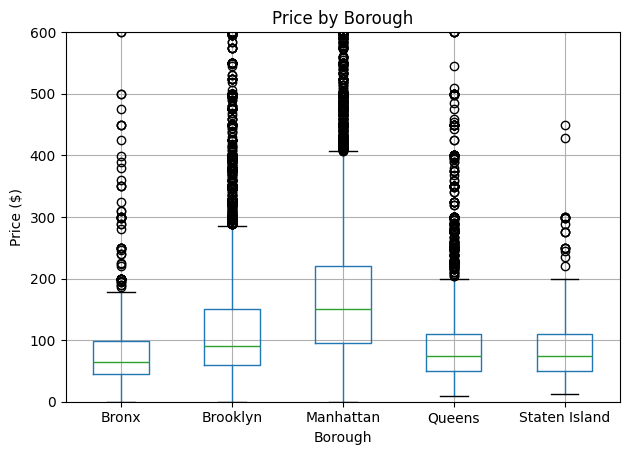

In [10]:
# Price by borough
plt.figure(figsize=(8, 5))
df.boxplot(column="price", by="neighbourhood_group")
plt.title("Price by Borough")
plt.xlabel("Borough")
plt.ylabel("Price ($)")
plt.ylim(0, 600)
plt.suptitle("")
plt.tight_layout()
plt.savefig("./figures/eda_price_by_borough.png", dpi=150, bbox_inches="tight")
plt.show()

_Manhattan_ dominates with a median around $150 — nearly double every other borough. Its dense outlier cloud shows a large concentration of high-end listings.

_Brooklyn_ comes second with a median around $90, also with heavy outliers.

_Bronx_, _Queens_, and _Staten Island_ cluster together with medians around $65–$75 and tighter spreads.


We can either remove the outlier values or apply logarithmic transformation to compress the scale


**Outlier capping (winsorizing)** means clipping extreme values to a threshold. For example, if you cap at the 95th percentile, any price above that gets replaced with the 95th percentile value. This prevents a handful of $10,000/night listings from distorting your model's learning.


In [11]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower_bound) | (df["price"] > upper_bound)]
pct = len(outliers) / len(df) * 100

print(f"Outliers: {len(outliers)} out of {len(df)} ({pct:.2f}%)")
print(f"Bounds: ${lower_bound:.2f} – ${upper_bound:.2f}")

Outliers: 2972 out of 48895 (6.08%)
Bounds: $-90.00 – $334.00


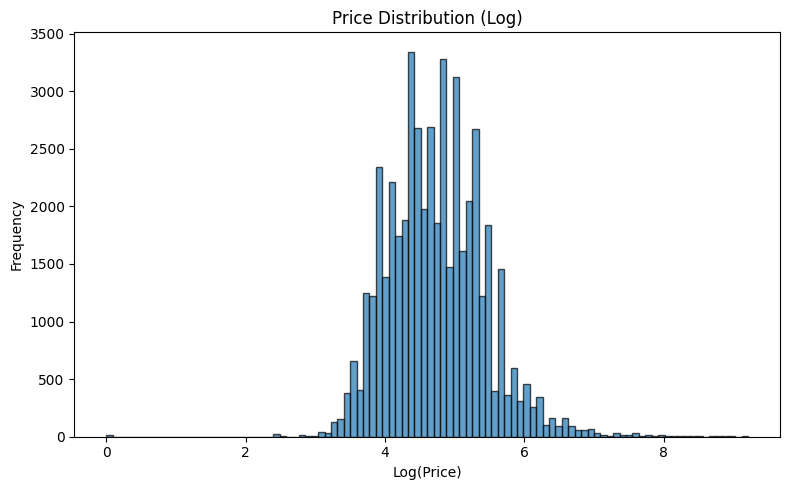

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"].apply(np.log1p), bins=100, edgecolor="black", alpha=0.7)
plt.title("Price Distribution (Log)")
plt.xlabel("Log(Price)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("./figures/eda_price_log.png", dpi=150, bbox_inches="tight")
plt.show()

Here, **Log(price)** means applying a **logarithmic transformation** to compress the scale. A $10 listing becomes ~2.3, a $100 listing becomes ~4.6, and a $1,000 listing becomes ~6.9. The gaps between extreme values shrink dramatically.


Most regression models (linear regression, random forest, etc.) perform better when the target variable is roughly normally distributed. As the histogram previously was heavily skewed to the after the log transformation the skew flattens out into a shape similar to bell curve


## 3. Data Cleaning and Preprocessing


In [13]:
df_t = df.copy()
print(f"Starting shape: {df_t.shape}")


Starting shape: (48895, 16)


In [14]:
# 3.1 Remove rows with price = 0 (invalid listings)
df_t = df_t[df_t["price"] > 0]
print(f"After removing price=0: {df_t.shape}")


After removing price=0: (48884, 16)


In [15]:
# 3.2 Handle missing values
df_t["reviews_per_month"] = df_t["reviews_per_month"].fillna(0)
df_t["last_review"] = pd.to_datetime(df_t["last_review"], errors="coerce")

print("Missing values after cleaning:")
print(df_t.isnull().sum()[df_t.isnull().sum() > 0])

Missing values after cleaning:
name              16
host_name         21
last_review    10051
dtype: int64


### Feature Engineering

In [16]:
# has_reviews: binary flag for whether the listing has any reviews
df_t["has_reviews"] = (df_t["number_of_reviews"] > 0).astype(int)

In [17]:
#days_since_last_review: recency of engagement
max_date = df_t["last_review"].max()
df_t["days_since_last_review"] = (max_date - df_t["last_review"]).dt.days

In [18]:
# -1 for never reviewed
df_t["days_since_last_review"] = df_t["days_since_last_review"].fillna(-1)

In [19]:
# is_high_availability: listing available more than half the year
df_t["is_high_availability"] = (df_t["availability_365"] > 182).astype(int)

In [20]:
# is_multi_lister: host has more than 1 listing
df_t["is_multi_lister"] = (
    df_t["calculated_host_listings_count"] > 1).astype(int)

In [21]:
# log_price: log-transform the target to handle right skewness
df_t["log_price"] = np.log1p(df_t["price"])

In [22]:
print("New features created:")
print(df_t[["has_reviews", "days_since_last_review", "is_high_availability",
            "is_multi_lister", "log_price"]].describe())

New features created:
        has_reviews  days_since_last_review  is_high_availability  \
count  48884.000000            48884.000000          48884.000000   
mean       0.794391              219.799178              0.292672   
std        0.404150              385.667293              0.454994   
min        0.000000               -1.000000              0.000000   
25%        1.000000                4.000000              0.000000   
50%        1.000000               24.000000              0.000000   
75%        1.000000              246.000000              1.000000   
max        1.000000             3024.000000              1.000000   

       is_multi_lister     log_price  
count     48884.000000  48884.000000  
mean          0.339232      4.737951  
std           0.473453      0.691782  
min           0.000000      2.397895  
25%           0.000000      4.248495  
50%           0.000000      4.672829  
75%           1.000000      5.170484  
max           1.000000      9.210440  


### Outlir Handling

In [23]:
# Cap price at 99.5th percentile ($1,000) and minimum_nights at 99th percentile (45)
price_cap = df_t["price"].quantile(0.995)
nights_cap = df_t["minimum_nights"].quantile(0.99)

print(f"Price cap (99.5th percentile): ${price_cap:.0f}")
print(f"Minimum nights cap (99th percentile): {nights_cap:.0f} nights")

df_t_before = len(df_t)
df_t = df_t[(df_t["price"] <= price_cap) & (
    df_t["minimum_nights"] <= nights_cap)]
print(f"Rows removed by outlier filtering: {df_t_before - len(df_t):,}")
print(f"Final shape after outlier handling: {df_t.shape}")

Price cap (99.5th percentile): $1000
Minimum nights cap (99th percentile): 45 nights
Rows removed by outlier filtering: 686
Final shape after outlier handling: (48198, 21)


In [24]:
# Recalculate log_price after filtering
df_t["log_price"] = np.log1p(df_t["price"])

### Encode Categorical Variables

In [25]:
# One-hot encode room_type (3 categories)
df_t = pd.get_dummies(df_t, columns=["room_type"], drop_first=True, dtype=int)

# Label encode neighbourhood_group
df_t = pd.get_dummies(
    df_t, columns=["neighbourhood_group"], drop_first=True, dtype=int)

# neighbourhood has 221 unique values — use frequency encoding
neighbourhood_freq = df_t["neighbourhood"].value_counts(normalize=True)
df_t["neighbourhood_freq"] = df_t["neighbourhood"].map(neighbourhood_freq)

print("Encoded features:")
print([c for c in df_t.columns if "room_type_" in c or "neighbourhood_group_" in c or c == "neighbourhood_freq"])

Encoded features:
['room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'neighbourhood_freq']


In [26]:
# Drop columns not needed for modeling
drop_cols = ["id", "name", "host_id", "host_name", "neighbourhood",
             "last_review", "price"]  # using log_price as target

df_model = df_t.drop(columns=[c for c in drop_cols if c in df.columns])

print("Final feature set:")
print(df_model.columns.tolist())
print(f"\nShape: {df_model.shape}")
print(f"\nAny remaining nulls: {df_model.isnull().sum().sum()}")

Final feature set:
['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'has_reviews', 'days_since_last_review', 'is_high_availability', 'is_multi_lister', 'log_price', 'room_type_Private room', 'room_type_Shared room', 'neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island', 'neighbourhood_freq']

Shape: (48198, 19)

Any remaining nulls: 0


### Splitting Dataset

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
TARGET = "log_price"

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

# Scale numerical features
scaler = StandardScaler()
numerical_features = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
                      "reviews_per_month", "calculated_host_listings_count",
                      "availability_365", "days_since_last_review", "neighbourhood_freq"]

X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

print("\nScaling applied to numerical features.")

Training set: (38558, 18)
Test set:     (9640, 18)

Scaling applied to numerical features.


## 4. Model Development & MLflow Experiment Tracking

We train and compare three regression models, logging all experiments with MLflow:

1. **Linear Regression** — Baseline model
2. **Random Forest Regressor** — Ensemble tree-based model
3. **XGBoost Regressor** — Gradient boosting model


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [30]:
mlflow.set_tracking_uri("mlruns")  

EXPERIMENT_NAME = "StayWise_Airbnb_Price_Prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

2026/04/05 21:18:29 INFO mlflow.tracking.fluent: Experiment with name 'StayWise_Airbnb_Price_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///j:/MLflow/assignment_3/mlruns/562232205215858156', creation_time=1775438309740, experiment_id='562232205215858156', last_update_time=1775438309740, lifecycle_stage='active', name='StayWise_Airbnb_Price_Prediction', tags={}>

In [31]:
def evaluate_model(y_true, y_pred):
    """Calculate regression metrics on log-scale and original-scale."""
    # Log-scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_log = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Original-scale metrics (expm1 to reverse log1p)
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred)
    rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae_orig = mean_absolute_error(y_true_orig, y_pred_orig)

    return {
        "rmse_log": rmse_log,
        "mae_log": mae_log,
        "r2_score": r2,
        "rmse_dollars": rmse_orig,
        "mae_dollars": mae_orig
    }

In [32]:
def train_and_log_model(model, model_name, params, X_train, X_test, y_train, y_test):
    """Train a model, evaluate it, and log everything with MLflow."""
    with mlflow.start_run(run_name=model_name):
        # Train
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluate
        metrics = evaluate_model(y_test, y_pred)

        # Log parameters
        mlflow.log_params(params)
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("n_features", X_train.shape[1])
        mlflow.log_param("n_train_samples", X_train.shape[0])

        # Log metrics
        mlflow.log_metrics(metrics)

        # Log model
        if "XGB" in model_name:
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        # Generate and log residual plot
        fig, ax = plt.subplots(figsize=(8, 5))
        residuals = y_test - y_pred
        ax.scatter(y_pred, residuals, alpha=0.3, s=10)
        ax.axhline(y=0, color="red", linestyle="--")
        ax.set_xlabel("Predicted (log price)")
        ax.set_ylabel("Residuals")
        ax.set_title(f"{model_name} — Residual Plot")
        plot_path = f"./figures/residuals_{model_name.lower().replace(' ', '_')}.png"
        fig.savefig(plot_path, dpi=150, bbox_inches="tight")
        mlflow.log_artifact(plot_path)
        plt.show()

        # Print results
        print(f"\n{'='*50}")
        print(f" {model_name} Results")
        print(f"{'='*50}")
        print(f" R² Score:       {metrics['r2_score']:.4f}")
        print(f" RMSE (log):     {metrics['rmse_log']:.4f}")
        print(f" MAE (log):      {metrics['mae_log']:.4f}")
        print(f" RMSE (dollars): ${metrics['rmse_dollars']:.2f}")
        print(f" MAE (dollars):  ${metrics['mae_dollars']:.2f}")

        run_id = mlflow.active_run().info.run_id

    return metrics, run_id

### Model 1: Linear Regression (Baseline)


2026/04/05 21:18:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 21:18:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


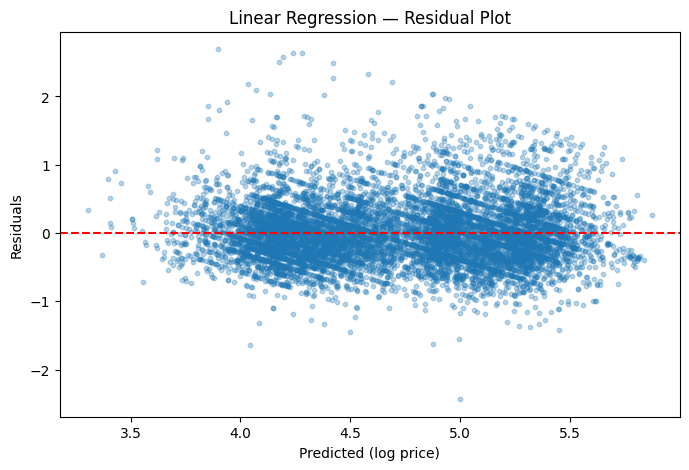


 Linear Regression Results
 R² Score:       0.5425
 RMSE (log):     0.4493
 MAE (log):      0.3385
 RMSE (dollars): $99.59
 MAE (dollars):  $51.67


In [33]:
lr_model = LinearRegression()
lr_params = {"fit_intercept": True}

lr_metrics, lr_run_id = train_and_log_model(
    lr_model, "Linear Regression", lr_params,
    X_train, X_test, y_train, y_test
)

### Model 2: Random Forest Regressor


2026/04/05 21:18:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/05 21:18:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


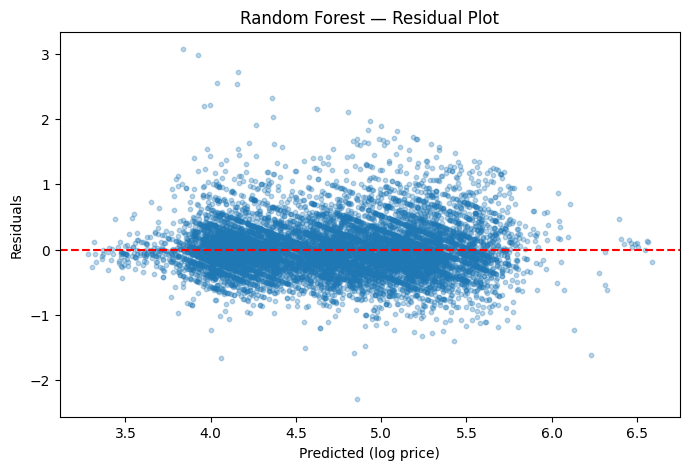


 Random Forest Results
 R² Score:       0.6379
 RMSE (log):     0.3998
 MAE (log):      0.2933
 RMSE (dollars): $90.86
 MAE (dollars):  $45.96


In [34]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": 200,
    "max_depth": 15,
    "min_samples_split": 10,
    "min_samples_leaf": 5,
    "random_state": 42
}

rf_metrics, rf_run_id = train_and_log_model(
    rf_model, "Random Forest", rf_params,
    X_train, X_test, y_train, y_test
)

### Model 3: XGBoost Regressor


2026/04/05 21:18:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
j:\MLflow\.mlflow\lib\site-packages\xgboost\core.py:158: UserWarning: [21:18:36] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  warnings.warn(smsg, UserWarning)
2026/04/05 21:18:38 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


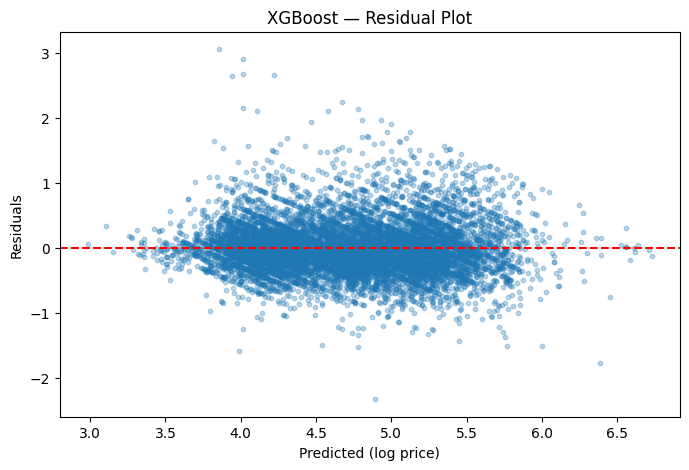


 XGBoost Results
 R² Score:       0.6416
 RMSE (log):     0.3977
 MAE (log):      0.2928
 RMSE (dollars): $89.45
 MAE (dollars):  $45.65


In [35]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": 300,
    "max_depth": 8,
    "learning_rate": 0.1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "random_state": 42
}

xgb_metrics, xgb_run_id = train_and_log_model(
    xgb_model, "XGBoost", xgb_params,
    X_train, X_test, y_train, y_test
)

## 5. Model Comparison


In [36]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R² Score": [lr_metrics["r2_score"], rf_metrics["r2_score"], xgb_metrics["r2_score"]],
    "RMSE (log)": [lr_metrics["rmse_log"], rf_metrics["rmse_log"], xgb_metrics["rmse_log"]],
    "MAE (log)": [lr_metrics["mae_log"], rf_metrics["mae_log"], xgb_metrics["mae_log"]],
    "RMSE ($)": [lr_metrics["rmse_dollars"], rf_metrics["rmse_dollars"], xgb_metrics["rmse_dollars"]],
    "MAE ($)": [lr_metrics["mae_dollars"], rf_metrics["mae_dollars"], xgb_metrics["mae_dollars"]],
})

results = results.sort_values(
    "R² Score", ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

            Model  R² Score  RMSE (log)  MAE (log)  RMSE ($)   MAE ($)
          XGBoost  0.641578    0.397698   0.292783 89.446236 45.654688
    Random Forest  0.637864    0.399754   0.293299 90.864346 45.960105
Linear Regression  0.542488    0.449322   0.338518 99.591716 51.673727


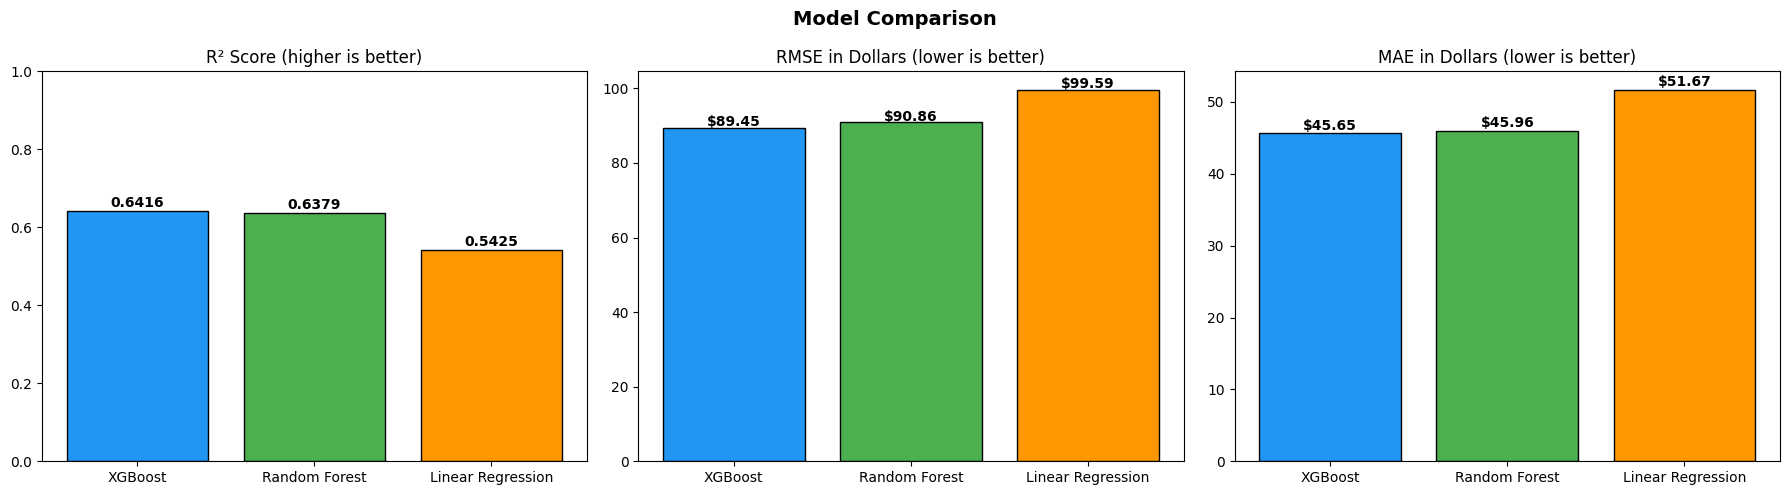

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = results["Model"]
colors = ["#2196F3", "#4CAF50", "#FF9800"]

# R² Score
axes[0].bar(models, results["R² Score"], color=colors, edgecolor="black")
axes[0].set_title("R² Score (higher is better)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(results["R² Score"]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

# RMSE ($)
axes[1].bar(models, results["RMSE ($)"], color=colors, edgecolor="black")
axes[1].set_title("RMSE in Dollars (lower is better)")
for i, v in enumerate(results["RMSE ($)"]):
    axes[1].text(i, v + 0.5, f"${v:.2f}", ha="center", fontweight="bold")

# MAE ($)
axes[2].bar(models, results["MAE ($)"], color=colors, edgecolor="black")
axes[2].set_title("MAE in Dollars (lower is better)")
for i, v in enumerate(results["MAE ($)"]):
    axes[2].text(i, v + 0.5, f"${v:.2f}", ha="center", fontweight="bold")

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("./figures/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

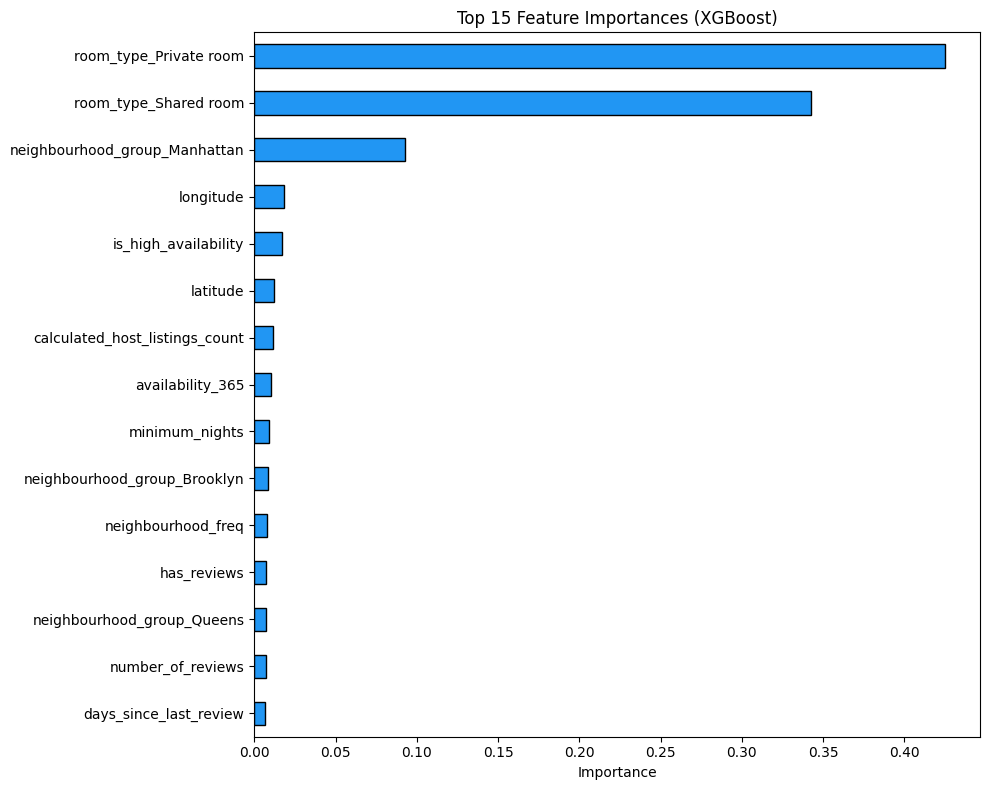

In [38]:
feature_imp = pd.Series(
    xgb_model.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feature_imp.tail(15).plot(kind="barh", color="#2196F3", edgecolor="black")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("./figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Register Best Model in MLflow Model Registry


In [39]:
all_results = {
    "Linear Regression": {"metrics": lr_metrics, "run_id": lr_run_id},
    "Random Forest":     {"metrics": rf_metrics, "run_id": rf_run_id},
    "XGBoost":           {"metrics": xgb_metrics, "run_id": xgb_run_id},
}

best_model_name = max(
    all_results, key=lambda k: all_results[k]["metrics"]["r2_score"])
best_run_id = all_results[best_model_name]["run_id"]
best_r2 = all_results[best_model_name]["metrics"]["r2_score"]

print(f"Best model: {best_model_name}")
print(f"R² Score:   {best_r2:.4f}")
print(f"Run ID:     {best_run_id}")

# Register in MLflow Model Registry
model_uri = f"runs:/{best_run_id}/model"
registered_model = mlflow.register_model(
    model_uri=model_uri,
    name="StayWise_Price_Predictor"
)

print(f"\nModel registered as: {registered_model.name}")
print(f"Version: {registered_model.version}")

Successfully registered model 'StayWise_Price_Predictor'.
2026/04/05 21:18:39 WARNING mlflow.tracking._model_registry.fluent: Run with id a893f35983d147c799d24ad37e53dc95 has no artifacts at artifact path 'model', registering model based on models:/m-ba37b226bcdd480684598a264cad4b7f instead


Best model: XGBoost
R² Score:   0.6416
Run ID:     a893f35983d147c799d24ad37e53dc95

Model registered as: StayWise_Price_Predictor
Version: 1


Created version '1' of model 'StayWise_Price_Predictor'.


In [40]:
client = mlflow.tracking.MlflowClient()

client.set_registered_model_alias(
    name="StayWise_Price_Predictor",
    alias="production",
    version=registered_model.version
)

print(f"Model '{registered_model.name}' v{registered_model.version} → 'production' alias")

Model 'StayWise_Price_Predictor' v1 → 'production' alias
